# Forberedelsen af data

In [95]:
#Libriaries & Models
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

from IPython.display import clear_output
from skimage.io import imread
from skimage.transform import resize

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

from scipy.spatial.distance import cdist
from scipy.linalg import pinv
from sklearn.metrics import mean_squared_error


Upload data

In [5]:
#from google.colab import drive
#drive.mount('/content/drive')

Set path for our project

In [7]:
#drive_path = '/content/drive/MyDrive/00_DTU/5. Semester/Deep Learning/02456-deep-learning-project-main/data/raw'
local_path = r'C:\Users\julia\OneDrive\Dokumente\GitHub\02456-deep-learning-project\data\raw'  # if you're folder structure is as defined above and you want to run locally

Access the datasets

In [9]:
# Find all CSV files in the specified path
csv_files = glob.glob(os.path.join(local_path, 'wind_speed_*.csv'))

# Read each CSV file into a DataFrame and store in a dictionary
dataframes = {}
for file in csv_files:
    df_name = os.path.basename(file).replace(".csv", "")  # Extract file name without extension
    dataframes[df_name] = pd.read_csv(file)

# Display keys (file names) to ensure everything loaded correctly
print("Loaded datasets:", list(dataframes.keys()))


Loaded datasets: ['wind_speed_11_n', 'wind_speed_13_n', 'wind_speed_15_n', 'wind_speed_17_n', 'wind_speed_19_n']


In [10]:
# For eksempel for at få adgang til 'wind_speed_11_n' data
wind_speed_11_df = dataframes['wind_speed_15_n']
print(wind_speed_11_df.head())  # Se de første par rækker af dataene


           Mx1          Mx2         Mx3          My1          My2  \
0  5135.514141  -632.018403 -502.290212  8804.933549  3930.929887   
1  5446.065240 -1112.603015 -286.715582  8293.780681  4337.857944   
2  5001.160903  -547.519926 -504.268986  8655.390593  3854.436694   
3  4875.234131  -642.151129 -386.656840  8302.786656  4538.536744   
4  4872.189068  -643.406021 -126.689990  8230.635251  4012.179658   

           My3        Mz1        Mz2        Mz3     Theta  ...       Vwy  \
0  7271.332052 -46.785316 -26.395576  24.996557  1.490672  ...  2.755655   
1  6767.032199 -45.441826 -25.880159  24.945032  1.526129  ...  2.658961   
2  6922.958281 -44.297226 -25.170956  24.973219  1.515226  ...  2.938581   
3  6603.542162 -42.947720 -24.713062  25.132181  1.541227  ...  3.106474   
4  6329.915987 -41.734791 -24.310396  25.351448  1.557755  ...  3.088724   

        Vwz     beta1     beta2     beta3    dbeta1    dbeta2    dbeta3  \
0 -0.005151  0.145057  0.144386  0.144536 -0.005971  

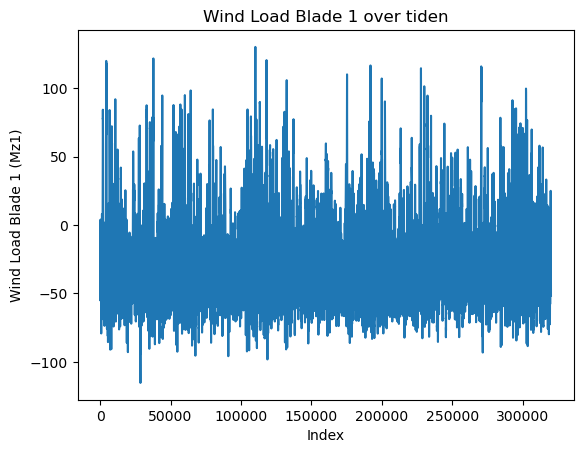

In [11]:
# Plotting et eksempel på Wind Load Blade 1 fra wind_speed_11_n
plt.plot(wind_speed_11_df['Mz1'])
plt.xlabel('Index')
plt.ylabel('Wind Load Blade 1 (Mz1)')
plt.title('Wind Load Blade 1 over tiden')
plt.show()


Samle alle datasets, så alt data bliver anvendt for modellen

In [13]:
# Læs og kombiner alle datasæt i én DataFrame
dataframes = [pd.read_csv(file) for file in csv_files]
combined_df = pd.concat(dataframes, ignore_index=True)

print("Kombineret datasæts form:", combined_df.shape)

Kombineret datasæts form: (1600005, 21)


Vælger de features der krav på at bruge til modellen og forbereder dataen.

In [123]:
# Select the input features we want to use
input_features = ['beta1', 'beta2', 'beta3', 'Theta', 'omega_r', 'Vwx']

# Select the output features we want to predict
output_features = ['Mz1', 'Mz2', 'Mz3']

# Filter data to only include the desired columns
filtered_df = combined_df[input_features + output_features]

# Normalize all features in the combined dataset
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(filtered_df)

# Convert back to a DataFrame to be able to access columns by name
combined_df_scaled = pd.DataFrame(scaled_data, columns=filtered_df.columns)



In [124]:
print(combined_df_scaled.head())
print(filtered_df.head())

      beta1     beta2     beta3     Theta   omega_r       Vwx       Mz1  \
0  0.005019  0.004973  0.005691  0.473178  0.583882  0.353673  0.422352   
1  0.004831  0.004775  0.005500  0.478704  0.585221  0.356892  0.422524   
2  0.006151  0.006086  0.006817  0.476996  0.585114  0.358844  0.423003   
3  0.004875  0.004797  0.005535  0.481046  0.583535  0.357451  0.422893   
4  0.006136  0.006045  0.006790  0.483619  0.581856  0.361800  0.423082   

        Mz2       Mz3  
0  0.711404  0.288507  
1  0.711774  0.287702  
2  0.711553  0.286894  
3  0.711542  0.286364  
4  0.711516  0.285869  
      beta1     beta2     beta3     Theta    omega_r        Vwx       Mz1  \
0 -0.000446 -0.000437 -0.000358  2.971328  11.904892  12.714500 -7.124377   
1 -0.000521 -0.000516 -0.000434  3.006740  11.912361  12.799350 -7.080373   
2  0.000004  0.000005  0.000090  2.995792  11.911765  12.850798 -6.957453   
3 -0.000503 -0.000507 -0.000420  3.021749  11.902957  12.814098 -6.985585   
4 -0.000001 -0.00001

In [129]:
import pandas as pd

def create_time_delayed_features_optimized(df, input_features, time_steps=3):
    """
    Create time-delayed features for a given DataFrame using vectorized operations.
    
    Args:
    - df: The DataFrame containing the scaled data.
    - input_features: The list of input feature names.
    - time_steps: The number of previous time steps to include (default is 3).
    
    Returns:
    - A DataFrame with time-delayed features.
    """
    delayed_df = pd.DataFrame(index=df.index)

    # For each feature, create shifted columns for each time delay and add to the DataFrame
    for feature in input_features:
        for t in range(time_steps + 1):
            delayed_df[f"{feature}_t-{t}"] = df[feature].shift(t)

    # Drop rows with NaN values (from initial time steps with no delay data)
    delayed_df.dropna(inplace=True)
    return delayed_df

# Create time-delayed features for the input features (using 3 previous time steps)
delayed_input_df = create_time_delayed_features_optimized(combined_df_scaled, input_features, time_steps=3)

# Merge the time-delayed input features with the original output features (Mz1, Mz2, Mz3)
final_df = pd.concat([delayed_input_df.reset_index(drop=True), combined_df_scaled[output_features].iloc[3:].reset_index(drop=True)], axis=1)

#rename the keys for input and output
all_features = final_df.columns
print(all_features)

#overwrite input features to match the added time delayed features
input_features = ['beta1_t-0', 'beta1_t-1', 'beta1_t-2', 'beta1_t-3', 'beta2_t-0',
       'beta2_t-1', 'beta2_t-2', 'beta2_t-3', 'beta3_t-0', 'beta3_t-1',
       'beta3_t-2', 'beta3_t-3', 'Theta_t-0', 'Theta_t-1', 'Theta_t-2',
       'Theta_t-3', 'omega_r_t-0', 'omega_r_t-1', 'omega_r_t-2', 'omega_r_t-3',
       'Vwx_t-0', 'Vwx_t-1', 'Vwx_t-2', 'Vwx_t-3']
# View the final DataFrame with time-delayed features
print(final_df.head())


Index(['beta1_t-0', 'beta1_t-1', 'beta1_t-2', 'beta1_t-3', 'beta2_t-0',
       'beta2_t-1', 'beta2_t-2', 'beta2_t-3', 'beta3_t-0', 'beta3_t-1',
       'beta3_t-2', 'beta3_t-3', 'Theta_t-0', 'Theta_t-1', 'Theta_t-2',
       'Theta_t-3', 'omega_r_t-0', 'omega_r_t-1', 'omega_r_t-2', 'omega_r_t-3',
       'Vwx_t-0', 'Vwx_t-1', 'Vwx_t-2', 'Vwx_t-3', 'Mz1', 'Mz2', 'Mz3'],
      dtype='object')
   beta1_t-0  beta1_t-1  beta1_t-2  beta1_t-3  beta2_t-0  beta2_t-1  \
0   0.004875   0.006151   0.004831   0.005019   0.004797   0.006086   
1   0.006136   0.004875   0.006151   0.004831   0.006045   0.004797   
2   0.005086   0.006136   0.004875   0.006151   0.004978   0.006045   
3   0.005634   0.005086   0.006136   0.004875   0.005508   0.004978   
4   0.007990   0.005634   0.005086   0.006136   0.007847   0.005508   

   beta2_t-2  beta2_t-3  beta3_t-0  beta3_t-1  ...  omega_r_t-1  omega_r_t-2  \
0   0.004775   0.004973   0.005535   0.006817  ...     0.585114     0.585221   
1   0.006086   0.00477

In [131]:
print(final_df[input_features].head())

   beta1_t-0  beta1_t-1  beta1_t-2  beta1_t-3  beta2_t-0  beta2_t-1  \
0   0.004875   0.006151   0.004831   0.005019   0.004797   0.006086   
1   0.006136   0.004875   0.006151   0.004831   0.006045   0.004797   
2   0.005086   0.006136   0.004875   0.006151   0.004978   0.006045   
3   0.005634   0.005086   0.006136   0.004875   0.005508   0.004978   
4   0.007990   0.005634   0.005086   0.006136   0.007847   0.005508   

   beta2_t-2  beta2_t-3  beta3_t-0  beta3_t-1  ...  Theta_t-2  Theta_t-3  \
0   0.004775   0.004973   0.005535   0.006817  ...   0.478704   0.473178   
1   0.006086   0.004775   0.006790   0.005535  ...   0.476996   0.478704   
2   0.004797   0.006086   0.005729   0.006790  ...   0.481046   0.476996   
3   0.006045   0.004797   0.006265   0.005729  ...   0.483619   0.481046   
4   0.004978   0.006045   0.008610   0.006265  ...   0.481935   0.483619   

   omega_r_t-0  omega_r_t-1  omega_r_t-2  omega_r_t-3   Vwx_t-0   Vwx_t-1  \
0     0.583535     0.585114     0.58522

# Oprettelsen af modellen

Vælger de variabler som skal bruge til at predicte output variablerne
og sætter mængden af dataen som skal trænes, og mængden som skal testes

her fra har vi sat test størrelsen på 0.20 %

# RBF - Implementation

In [133]:
class RBFNetwork:
    def __init__(self, centers, sigma=1.0):
        self.centers = centers  # Centrene for RBF-enhederne (det skjulte lag)
        self.sigma = sigma      # Spredningsparameter for Gaussian-funktionen
        self.weights = None     # Vægte til outputlaget

    def _rbf(self, X):
        # Calculates radial basis functions (Gaussian) for input X
        distances = cdist(X, self.centers, 'euclidean')  # Distance from input to each center
        return np.exp(-distances ** 2 / (2 * self.sigma ** 2))  # Gaussian RBF

    def fit(self, X, y):
    # Train the model (calculate weights based on target variable y)
    G = self._rbf(X)  # Calculate activations in the hidden layer
    self.weights = pinv(G).dot(y)  # Calculate weights for the output layer (using pseudo-inverse)


    def predict(self, X):
        # Forudsig output for nye data
        G = self._rbf(X)
        return G.dot(self.weights)


In [190]:
# set test and train and centers for the model 
X = final_df[input_features]   # Input variables
y = final_df[output_features]  # Output variables

# Split dataene i træning og test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Antag at X_train er en NumPy-array (hvis det er en DataFrame, konverter den med .values)
X_train = X_train.values if hasattr(X_train, 'values') else X_train
y_train = y_train.values if hasattr(y_train, 'values') else y_train

#calculating the cluster centers for different numbers of clusters

centers_list = [] #maybe it is better to use a dictionary and have the no. of centers as a key?
num_centers_list = [1,10,20,50] #,100, 150] # Set the number of RBF centers (same as the number of clusters)
for num_center in num_centers_list:
    # Apply K-Means to X_train to find cluster centers
    kmeans = KMeans(n_clusters=num_center, n_init=10, random_state=0)
    kmeans.fit(X_train)
    
    # The cluster centers will serve as the RBF centers
    centers = kmeans.cluster_centers_
    centers_list.append(centers)




In [191]:
print(centers_list)

[array([[0.40135354, 0.40135218, 0.40135209, 0.4013519 , 0.40163223,
        0.40163085, 0.40163075, 0.40163056, 0.40221313, 0.40221177,
        0.40221169, 0.40221151, 0.49968466, 0.49969556, 0.49970515,
        0.49970465, 0.5997731 , 0.59977114, 0.59977344, 0.59977371,
        0.44646593, 0.44646347, 0.44646032, 0.44646002]]), array([[0.53168499, 0.53167778, 0.53167437, 0.53167203, 0.5328765 ,
        0.53287795, 0.53288314, 0.53288934, 0.53234011, 0.53233929,
        0.53234227, 0.53234631, 0.83027319, 0.83280929, 0.83157733,
        0.83033679, 0.62259416, 0.62261952, 0.62265159, 0.62268271,
        0.48782574, 0.48782432, 0.48781723, 0.48782772],
       [0.02304552, 0.02305018, 0.02305538, 0.02306198, 0.02417346,
        0.02418181, 0.02419066, 0.02420085, 0.02365122, 0.0236655 ,
        0.02368033, 0.02369655, 0.74053353, 0.74171796, 0.74182318,
        0.74064255, 0.52840823, 0.52833694, 0.52826776, 0.52820433,
        0.28941781, 0.28941717, 0.28939506, 0.28938427],
       [0.

# Tuning of parameters - sigma and no. of centers

Mean Squared Error of train data: 0.042778198059948126 Mean Squared Error testdata: 0.042542224266799634
Mean Squared Error of train data: 0.00821790522876569 Mean Squared Error testdata: 0.008184300128895082
Mean Squared Error of train data: 0.004757921272037005 Mean Squared Error testdata: 0.004739097497014071
Mean Squared Error of train data: 0.0032836116917705593 Mean Squared Error testdata: 0.0032779974185667207
[0.042778198059948126, 0.00821790522876569, 0.004757921272037005, 0.0032836116917705593] [0.042542224266799634, 0.008184300128895082, 0.004739097497014071, 0.0032779974185667207]


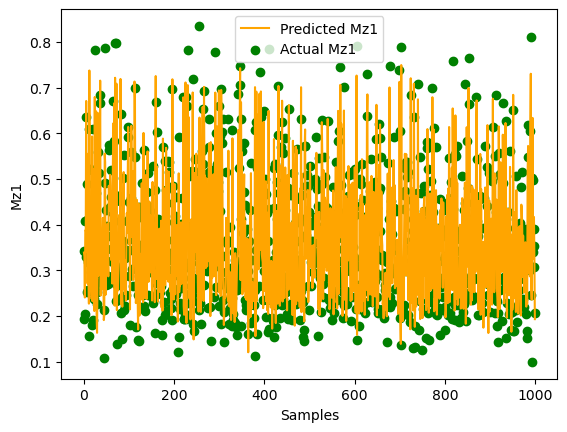

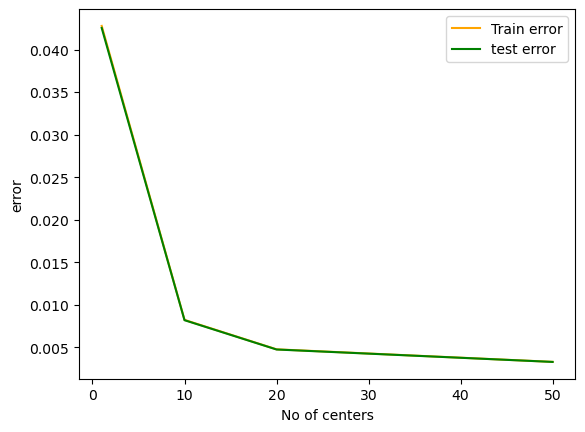

In [196]:
#tuning no. of centers and printing results
mse_train_list = []
mse_test_list = []
sigma = 1
for index in range(4):
    rbf_net = RBFNetwork(centers_list[index], sigma)
    rbf_net.fit(X_train, y_train)

    y_train_pred = rbf_net.predict(X_train)
    y_pred = rbf_net.predict(X_test)
        
    # calculate MSE
    mse_train = mean_squared_error(y_train,y_train_pred)
    mse_test = mean_squared_error(y_test, y_pred)
    print("Mean Squared Error of train data:",  mse_train, "Mean Squared Error testdata:", mse_test)
    mse_train_list.append(mse_train)
    mse_test_list.append(mse_test)

print(mse_train_list, mse_test_list)

#plotting the errors
plt.plot(range(1000), y_pred[:1000, 0], label='Predicted Mz1', color = 'orange')
plt.scatter(range(1000),y_test.iloc[:1000, 0], label='Actual Mz1', color='green')
plt.xlabel('Samples')
plt.ylabel('Mz1')
plt.legend()
plt.show()


#plotting the model prediction
plt.plot(num_centers_list, mse_train_list, label='Train error', color = 'orange')
plt.plot(num_centers_list,mse_test_list, label='test error', color='green')
plt.xlabel('No of centers')
plt.ylabel('error')
plt.legend()
plt.show()


sigma:0.4 Mean Squared Error of train data: 0.11792489060338458 Mean Squared Error testdata: 0.11749184294247672
sigma:0.8 Mean Squared Error of train data: 0.05900336312631111 Mean Squared Error testdata: 0.05867337847026066
sigma:1.0 Mean Squared Error of train data: 0.042778198059948126 Mean Squared Error testdata: 0.042542224266799634
sigma:1.2 Mean Squared Error of train data: 0.03378757030304444 Mean Squared Error testdata: 0.03361298236437884
sigma:1.4 Mean Squared Error of train data: 0.028869992541956508 Mean Squared Error testdata: 0.028732004818615486
sigma:2.0 Mean Squared Error of train data: 0.02342579613312259 Mean Squared Error testdata: 0.023333781047561303
[0.11792489060338458, 0.05900336312631111, 0.042778198059948126, 0.03378757030304444, 0.028869992541956508, 0.02342579613312259] [0.11749184294247672, 0.05867337847026066, 0.042542224266799634, 0.03361298236437884, 0.028732004818615486, 0.023333781047561303]


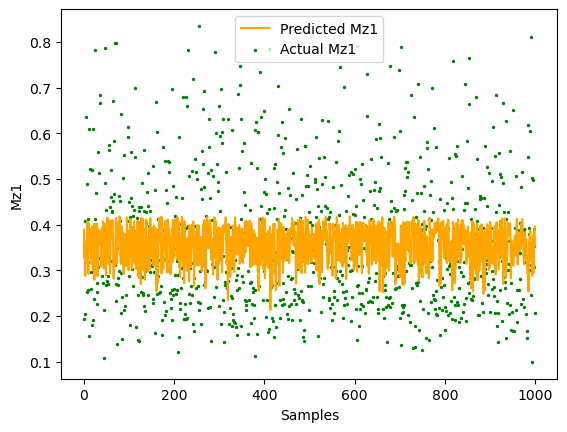

In [154]:
#tuning sigma and printing the results for time delayed model
sigma_list = [0.4, 0.8, 1.0, 1.2, 1.4, 2.0] 
mse_train_list = []
mse_test_list = []
for sigma in sigma_list:
    rbf_net = RBFNetwork(centers, sigma)
    rbf_net.fit(X_train, y_train)

    y_train_pred = rbf_net.predict(X_train)
    y_pred = rbf_net.predict(X_test)
        
    # calculate MSE
    mse_train = mean_squared_error(y_train,y_train_pred)
    mse_test = mean_squared_error(y_test, y_pred)
    print(f'sigma:{sigma}',"Mean Squared Error of train data:",  mse_train, "Mean Squared Error testdata:", mse_test)
    mse_train_list.append(mse_train)
    mse_test_list.append(mse_test)

print(mse_train_list, mse_test_list)
plt.plot(range(1000), y_pred[:1000, 0], label='Predicted Mz1', color = 'orange')
plt.scatter(range(1000),y_test.iloc[:1000, 0], label='Actual Mz1', color='green', s=2)
plt.xlabel('Samples')
plt.ylabel('Mz1')
plt.legend()
plt.show()


#comparing test and train accuarcies

# Old model for comparison 

In [ ]:
#old model without time delay for comparison 


# set test and train and centers for the model 
X = combined_df_scaled[input_features]   # Input variables
y = combined_df_scaled[output_features]  # Output variables

# Split dataene i træning og test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Antag at X_train er en NumPy-array (hvis det er en DataFrame, konverter den med .values)
X_train = X_train.values if hasattr(X_train, 'values') else X_train
y_train = y_train.values if hasattr(y_train, 'values') else y_train


num_centers = 1  # Set the number of RBF centers (same as the number of clusters)
# Apply K-Means to X_train to find cluster centers
kmeans = KMeans(n_clusters=num_centers, n_init=10, random_state=0)
kmeans.fit(X_train)



Mean Squared Error på testdata: 0.014263963195322601


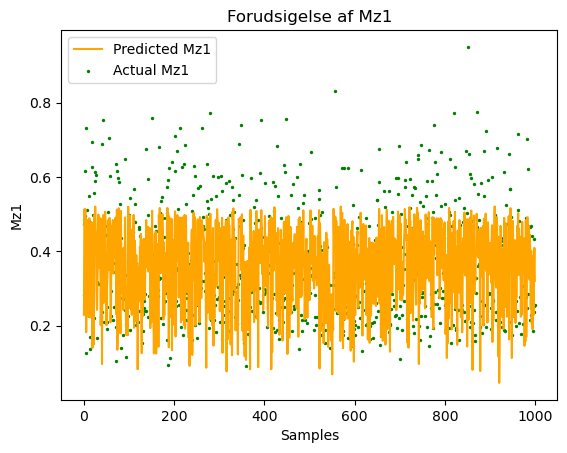

In [115]:
#results of the model without time delay for comparison


rbf_net = RBFNetwork(centers, sigma=1.0)
rbf_net.fit(X_train, y_train)

y_pred = rbf_net.predict(X_test)


# Beregn MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error på testdata:", mse)


plt.plot(range(1000), y_pred[:1000, 0], label='Predicted Mz1', color = 'orange')
plt.scatter(range(1000),y_test.iloc[:1000, 0], label='Actual Mz1', color='green', s=2)
plt.xlabel('Samples')
plt.ylabel('Mz1')
plt.legend()
plt.show()